In [1]:
from graphen import grphn
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
G = grphn()
G.N_recip = 250
G.set_FBZ()
VB, CB = G.E_Tb()


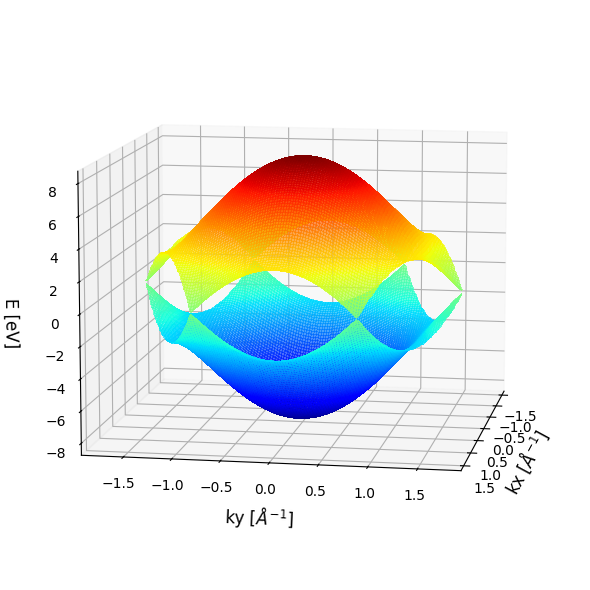

In [85]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')


E_min = min(np.nanmin(VB), np.nanmin(CB))
E_max = max(np.nanmax(VB), np.nanmax(CB))

# Bande de valence
ax.plot_surface(G.kxx, G.kyy, VB,
    rstride=2, cstride=2,
    cmap='jet',             
    vmin=E_min, vmax=E_max,
    linewidth=0, antialiased=False, alpha=0.7)

# Bande de conduction
ax.plot_surface(G.kxx, G.kyy, CB,
    rstride=2, cstride=2,
    cmap='jet',        
    vmin=E_min, vmax=E_max,
    linewidth=0, antialiased=False, alpha=0.7)

ax.set_xlabel(r'kx $[\AA^{-1}]$', fontsize=12)
ax.set_ylabel(r'ky $[\AA^{-1}]$', fontsize=12, labelpad=10)
ax.set_zlabel(r'E [eV]', fontsize=12, labelpad=10)
ax.view_init(10,10,0)

plt.tight_layout()
plt.savefig("LaTeX/asset/BS_TB.jpg",dpi=600)
plt.show()

In [9]:
G = grphn()
b = G.b

qx = np.linspace(-b/4,b/4,200)
qy = np.linspace(-b/4,b/4,200)
qxx_D, qyy_D = np.meshgrid(qx,qy)

G.set_recip_grid(qx+G.b_1[0]*(2/3)+G.b_2[0]/3,qy+G.b_1[1]*(2/3)+G.b_2[1]/3)
VB_K_D, CB_K_D = G.Dirac_c(qxx_D,qyy_D)

VB_K_Tb, CB_K_Tb = G.E_Tb()

In [29]:
# 1. Initialisation de ta classe (en supposant que grphn est importé)
graphene = grphn()

# 2. Point K
K_vec = graphene.b_1 * (2/3) + graphene.b_2 * (1/3)
K_x = K_vec[0]
K_y = K_vec[1]

# 3. Grille kx, ky
dkx = 0.7
dky = 0.7
kx = np.linspace(K_x - dkx, K_x + dkx, 150)
ky = np.linspace(K_y - dky+0.1, K_y + dky+0.1, 150)
kxx, kyy = np.meshgrid(kx, ky)

# 4. Calcul Tight-Binding
graphene.kxx = kxx
graphene.kyy = kyy
VB_K_Tb, CB_K_Tb = graphene.E_Tb(epsi=0)

# 5. Calcul Dirac
qxx = kxx - K_x
qyy = kyy - K_y
VB_K_D, CB_K_D = graphene.Dirac_c(qxx, qyy, epsi=0)

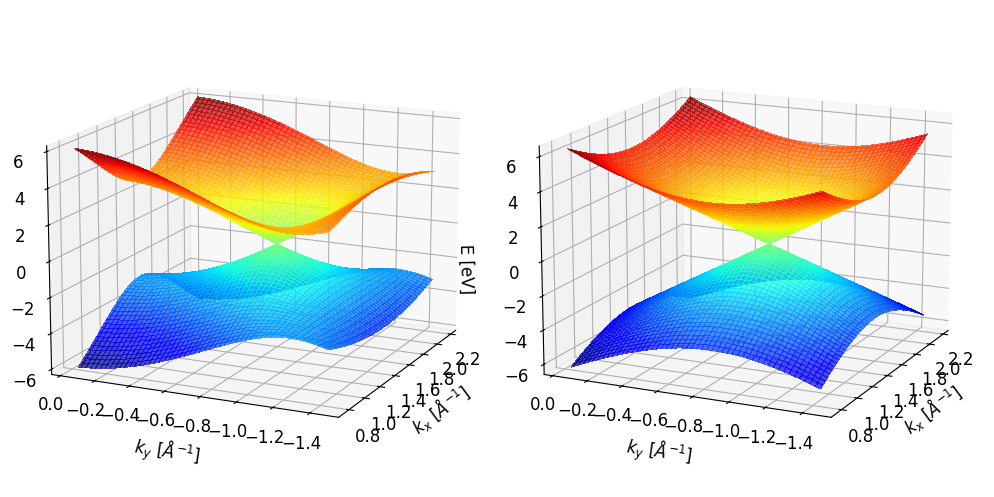

In [21]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(121, projection='3d')

# Normalisation commune pour les deux bandes
E_min = min(np.nanmin(VB_K_Tb), np.nanmin(CB_K_Tb))
E_max = max(np.nanmax(VB_K_Tb), np.nanmax(CB_K_Tb))

# Bande de valence
ax.plot_surface(kxx,kyy, VB_K_Tb,
    rstride=2, cstride=2,
    cmap='jet',             
    vmin=E_min, vmax=E_max,
    linewidth=0, antialiased=False, alpha=0.7)

# Bande de conduction
ax.plot_surface(kxx,kyy, CB_K_Tb,
    rstride=2, cstride=2,
    cmap='jet',        
    vmin=E_min, vmax=E_max,
    linewidth=0, antialiased=False, alpha=0.7)
# qx-G.b_1[0]*(2/3)-G.b_2[0]/3,qy-G.b_1[1]*(2/3)-G.b_2[1]/3
ax.set_xlabel(r'$k_x \ [\AA^{-1}]$', fontsize=12)
ax.set_ylabel(r'$k_y \ [\AA^{-1}]$', fontsize=12, labelpad=10)
ax.set_zlabel('E [eV]', fontsize=12, labelpad=10)
ax.tick_params(axis='both', labelsize=12)
ax.view_init(15,205,0)
# Approximation autour de K
ax1 = fig.add_subplot(122, projection='3d')

# Normalisation commune pour les deux bandes
E_min = min(VB_K_D.min(), CB_K_D.min())
E_max = max(VB_K_D.max(), CB_K_D.max())

# Bande de valence
ax1.plot_surface(kxx,kyy, VB_K_D,
    rstride=2, cstride=2,
    cmap='jet',             
    vmin=E_min, vmax=E_max,
    linewidth=0, antialiased=False, alpha=0.7)

# Bande de conduction
ax1.plot_surface(kxx,kyy, CB_K_D,
    rstride=2, cstride=2,
    cmap='jet',        
    vmin=E_min, vmax=E_max,
    linewidth=0, antialiased=False, alpha=0.7)


ax1.set_xlabel(r'$k_x \ [\AA^{-1}]$', fontsize=12)
ax1.set_ylabel(r'$k_y \ [\AA^{-1}]$', fontsize=12, labelpad=10)
ax1.set_zlabel('E [eV]', fontsize=12, labelpad=10)
ax1.tick_params(axis='both', labelsize=12)
ax1.view_init(15,205,0)


plt.tight_layout()
plt.savefig("LaTeX/asset/C_vs_BS.jpg",dpi=600)
plt.show()

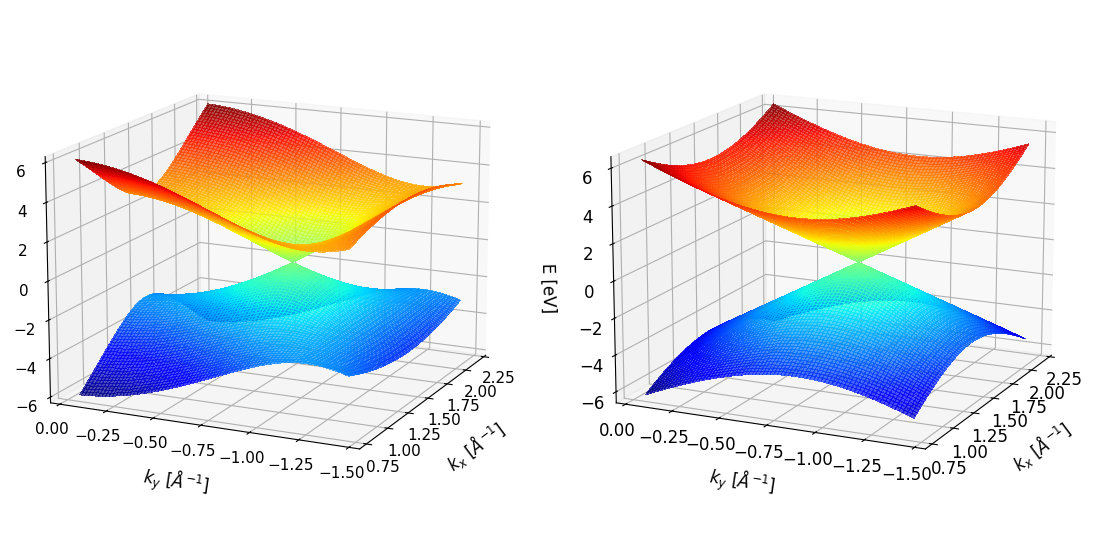

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# On élargit très légèrement la figure (de 10 à 12) pour donner de la place horizontale 
# entre les deux graphiques sans réduire leur hauteur (l'effet minuscule)
fig = plt.figure(figsize=(12, 6))

# ==================== GRAPHIQUE 1 ====================
ax = fig.add_subplot(121, projection='3d')

# Normalisation commune pour les deux bandes
E_min = min(np.nanmin(VB_K_Tb), np.nanmin(CB_K_Tb))
E_max = max(np.nanmax(VB_K_Tb), np.nanmax(CB_K_Tb))

# Bande de valence
ax.plot_surface(kxx,kyy, VB_K_Tb,
    rstride=2, cstride=2,
    cmap='jet',             
    vmin=E_min, vmax=E_max,
    linewidth=0, antialiased=False, alpha=0.7)

# Bande de conduction
ax.plot_surface(kxx,kyy, CB_K_Tb,
    rstride=2, cstride=2,
    cmap='jet',        
    vmin=E_min, vmax=E_max,
    linewidth=0, antialiased=False, alpha=0.7)

ax.set_xlabel(r'$k_x \ [\AA^{-1}]$', fontsize=12, labelpad=10)
ax.set_ylabel(r'$k_y \ [\AA^{-1}]$', fontsize=12, labelpad=10)
ax.set_zlabel('E [eV]', fontsize=12, labelpad=8)

# CORRECTION CHEVAUCHEMENT : Limite le nombre de ticks sans réduire le plot
ax.locator_params(axis='x', nbins=7)
ax.locator_params(axis='y', nbins=7)

# pad=2 éloigne un mini peu les nombres pour nettoyer la lecture
ax.tick_params(axis='both', labelsize=11, pad=2)
ax.view_init(15,205,0)

# ==================== GRAPHIQUE 2 ====================
# Approximation autour de K
ax1 = fig.add_subplot(122, projection='3d')

# Normalisation commune pour les deux bandes
E_min = min(VB_K_D.min(), CB_K_D.min())
E_max = max(VB_K_D.max(), CB_K_D.max())

# Bande de valence
ax1.plot_surface(kxx,kyy, VB_K_D,
    rstride=2, cstride=2,
    cmap='jet',             
    vmin=E_min, vmax=E_max,
    linewidth=0, antialiased=False, alpha=0.7)

# Bande de conduction
ax1.plot_surface(kxx,kyy, CB_K_D,
    rstride=2, cstride=2,
    cmap='jet',        
    vmin=E_min, vmax=E_max,
    linewidth=0, antialiased=False, alpha=0.7)

ax1.set_xlabel(r'$k_x \ [\AA^{-1}]$', fontsize=12, labelpad=10)
ax1.set_ylabel(r'$k_y \ [\AA^{-1}]$', fontsize=12, labelpad=10)
ax1.set_zlabel('E [eV]', fontsize=12, labelpad=6)

# CORRECTION CHEVAUCHEMENT (Suite)
ax1.locator_params(axis='x', nbins=7)
ax1.locator_params(axis='y', nbins=7)
ax1.tick_params(axis='both', labelsize=12, pad=2)

ax1.view_init(15,205,0)

# ==================== LAYOUT ET SAUVEGARDE ====================
# ON RETIRE `tight_layout` QUI ÉCRASE LES PLOTS 3D
# On force les graphes à occuper presque tout l'espace disponible (de 5% à 95%) 
plt.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95, wspace=0.1)

# bbox_inches='tight' est la vraie solution pour que Matplotlib calcule EXACTEMENT
# les bords de l'image Finale et n'ampute pas l'axe de gauche.
plt.savefig("LaTeX/asset/C_vs_BS.jpg", dpi=600, bbox_inches='tight', pad_inches=0.1)
plt.show()

In [9]:
from graphen import grphn
from scipy.ndimage import gaussian_filter1d
G = grphn()
G.set_FBZ()  # initialise self.kxx, self.kyy

# Calcul DOS
E_DOS, DOS, DOSp = G.DOS_chunked(n_points=30000, n_bins=1000,E_max=8.5)
# quick check
print(f"Nombre de points k dans la FBZ : {G.n_k_FBZ}")
print(f"E_DOS : [{E_DOS.min():.2f}, {E_DOS.max():.2f}] eV")
print(f"DOS max : {DOS.max():.4f} eV⁻¹")
print(f"Somme DOS * dE = {np.sum(DOS) * (E_DOS[1]-E_DOS[0]):.3f} ")

Nombre de points k dans la FBZ : 194847056
E_DOS : [-8.50, 8.50] eV
DOS max : 0.9644 eV⁻¹
Somme DOS * dE = 4.000 


/tmp/ipykernel_5677/2840966608.py:6: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "r-" (-> linestyle='-'). The keyword argument will take precedence.
  axes.plot(E_DOS,gaussian_filter1d(DOS,3),'r-',linestyle='--',zorder=5)
/tmp/ipykernel_5677/2840966608.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes.legend()


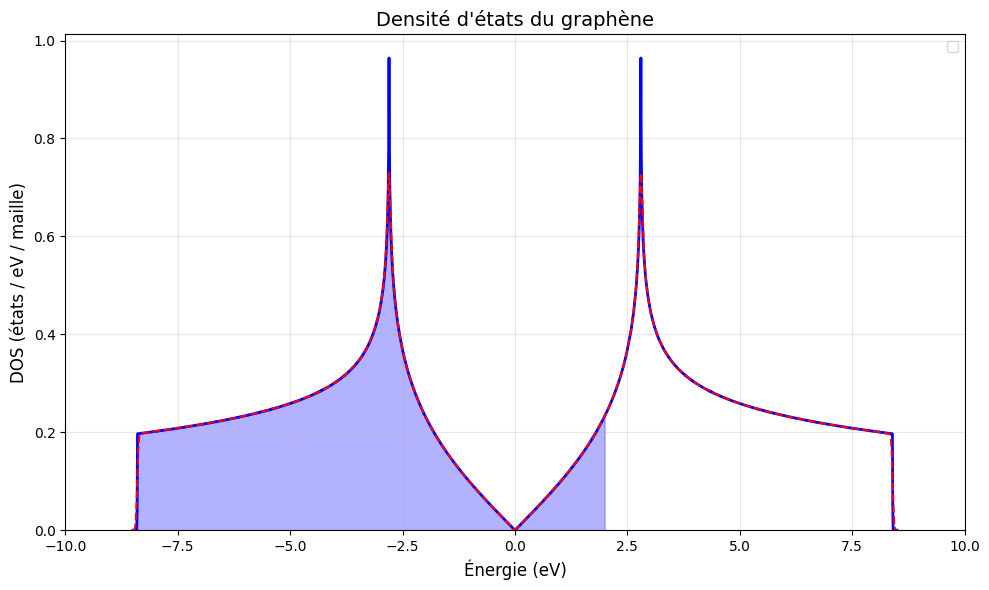

In [6]:
# dataconv = np.loadtxt('DOSNbin4000.txt')
# E_DOS = dataconv[:,0]
# DOS = dataconv[:,1]
E_f = 2
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
axes.plot(E_DOS,gaussian_filter1d(DOS,3),'r-',linestyle='--',zorder=5)
axes.plot(E_DOS, DOS, 'b-', linewidth=2)
axes.fill_between(E_DOS[E_DOS<E_f], 0, DOS[E_DOS<E_f], alpha=0.3, color='b')
# axes.axvline(x=E_f, color='r', linestyle='--', linewidth=1.5, label='Niveau de Fermi')
axes.set_xlabel('Énergie (eV)', fontsize=12)
axes.set_ylabel('DOS (états / eV / maille)', fontsize=12)
axes.set_title('Densité d\'états du graphène', fontsize=14)
axes.grid(True, alpha=0.3)
axes.set_ylim(bottom=0)
axes.set_xlim(-10, 10)
axes.legend()
plt.tight_layout()
plt.show()

/home/diego/Bureau/Code/PDR/graphen.py:233: RuntimeWarning: overflow encountered in cosh
  f_p = np.where(np.abs(x) < 80, 1 / (4 * kT_eV * np.cosh(x / 2)**2), 0.0)
/home/diego/Bureau/Code/PDR/graphen.py:233: RuntimeWarning: overflow encountered in square
  f_p = np.where(np.abs(x) < 80, 1 / (4 * kT_eV * np.cosh(x / 2)**2), 0.0)


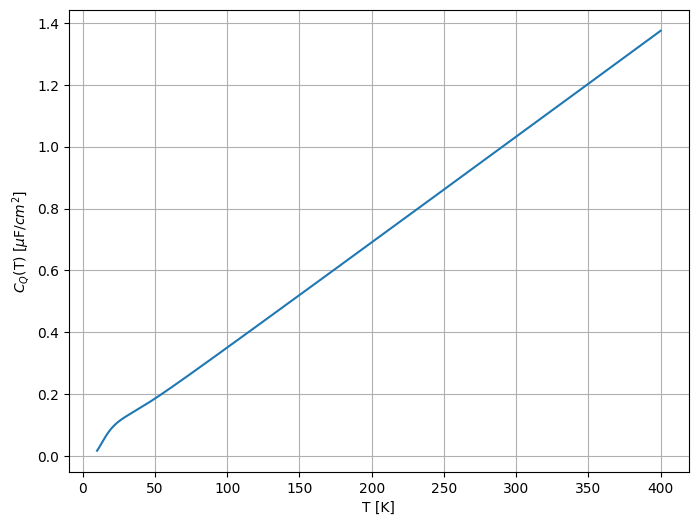

In [7]:
E = E_DOS
Fermilvl = 0
T = np.linspace(10,400,len(E))
# f = 1/(np.exp((E-Ef)/(k_B*t))+1)
C_qT = []

for t in T:
    cq = G.C_q(t,Fermilvl)
    C_qT.append(cq)

fig= plt.figure(figsize=(8,6))
ax = fig.add_subplot()

ax.grid(which='both')
ax.plot(T,np.array(C_qT))

ax.set_ylabel(r'$C_{Q}$(T) [$\mu$F/$cm^2$]')
ax.set_xlabel(r'T [K]')

plt.tight_layout
plt.show()

In [8]:
E = E_DOS
T = 10
Fermilvl = np.linspace(-0.2,0.2,len(E))
# f = 1/(np.exp((E-Ef)/(k_B*t))+1)
C_qE = []

for t in Fermilvl:
    cq = G.C_q(T,t)
    C_qE.append(cq)

fig= plt.figure(figsize=(8,6))
ax = fig.add_subplot()

ax.grid(which='both')
ax.plot(Fermilvl,np.array(C_qE))

ax.set_ylabel(r'$C_{Q}$(E) [$\mu$F/$cm^2$]')
ax.set_xlabel(r'E [eV]')

plt.tight_layout
plt.show()

# Problème ? Graphene science handbook p.6

NameError: name 'E_DOS' is not defined

In [10]:
T_arr = np.linspace(50, 900, 100)      
Ef_arr = np.linspace(-7.0, 7.0, 800)    

T_grid, Ef_grid = np.meshgrid(T_arr, Ef_arr)
C_q_3D = np.zeros_like(T_grid)

for i in range(T_grid.shape[0]):
    for j in range(T_grid.shape[1]):
        C_q_3D[i, j] = G.C_q(T_grid[i, j], Ef_grid[i, j])

/home/diego/Bureau/Code/PDR/graphen.py:233: RuntimeWarning: overflow encountered in cosh
  f_p = np.where(np.abs(x) < 80, 1 / (4 * kT_eV * np.cosh(x / 2)**2), 0.0)
/home/diego/Bureau/Code/PDR/graphen.py:233: RuntimeWarning: overflow encountered in square
  f_p = np.where(np.abs(x) < 80, 1 / (4 * kT_eV * np.cosh(x / 2)**2), 0.0)


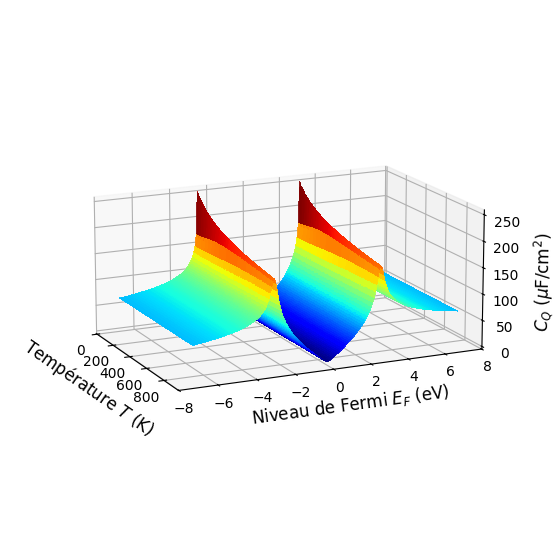

In [49]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16, 6))

ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(T_grid, Ef_grid, C_q_3D, 
                       cmap='jet',
                       edgecolor='none', 
                       alpha=0.9,
                       rcount=200,
                       ccount=200,
                       antialiased=False)     


# ========================================================
# 1. LE FIX PRINCIPAL : Le paramètre zoom dans l'aspect 
# (0.75 rend toute la structure plus petite au centre, 
# ce qui sauve les labels qui dépassent).
# ========================================================
ax.set_box_aspect((1.5, 2.3, 1.0), zoom=0.75) 

# Labels
ax.set_xlabel(r'Température $T$ (K)', fontsize=12, labelpad=10)
ax.set_ylabel(r'Niveau de Fermi $E_F$ (eV)', fontsize=12, labelpad=15)
ax.set_zlabel(r'$C_{Q}$ ($\mu$F/cm$^2$)', fontsize=12, labelpad=10)

ax.view_init(15, -25, 0)



# ========================================================
# 2. LA FORCE BRUTE POUR LES MARGES (On supprime tight_layout)
# ça force un espace libre à gauche, à droite, en haut et en bas.
# ========================================================
plt.subplots_adjust(left=0.05, right=0.9, top=1.0, bottom=0.1)


plt.savefig('QC_Ef_T.jpg', dpi=600, bbox_inches='tight')
plt.show()

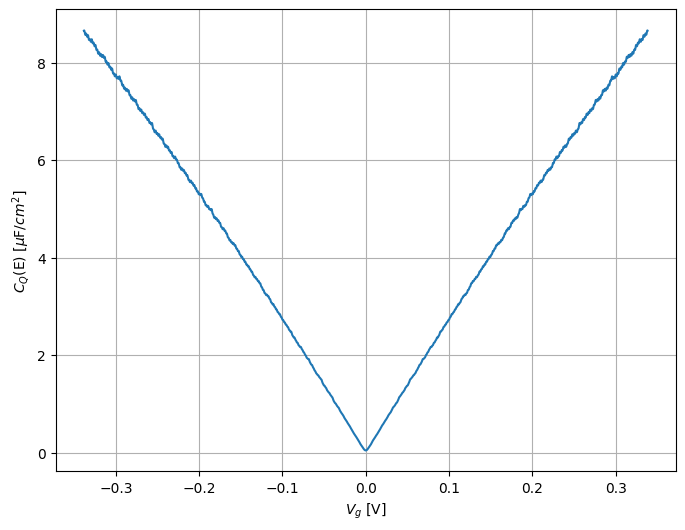

In [ ]:
E = E_DOS
T = 10
Fermilvl = np.linspace(-0.3,0.3,len(E))

eps_0 = 8.854e-14
eps_ox = 3.9
d_ox = 1e-8  # cm
C_ox = (eps_0 * eps_ox) / d_ox

Vg, n_porteurs, Ef_list = G.dep_Voltage(T=300, C_ox=C_ox,Ef_sup=0.3,Ef_inf=-0.3,N=len(E))

# f = 1/(np.exp((E-Ef)/(k_B*t))+1)
C_qE = []

for t in Fermilvl:
    cq = G.C_q(T,t)
    C_qE.append(cq)

fig= plt.figure(figsize=(8,6))
ax = fig.add_subplot()

ax.grid(which='both')
ax.plot(Vg,np.array(C_qE))

ax.set_ylabel(r'$C_{Q}$(E) [$\mu$F/$cm^2$]')
ax.set_xlabel(r'$V_g$ [V]')

plt.tight_layout
plt.show()

# Problème ? Graphene science handbook p.6
# La solution est dans la valeur de la vitesse de Fermi !

/home/diego/Bureau/Code/PDR/graphen.py:45: RuntimeWarning: overflow encountered in exp
  f = 1+np.exp((E-Ef)/(self.k_Bev*T))


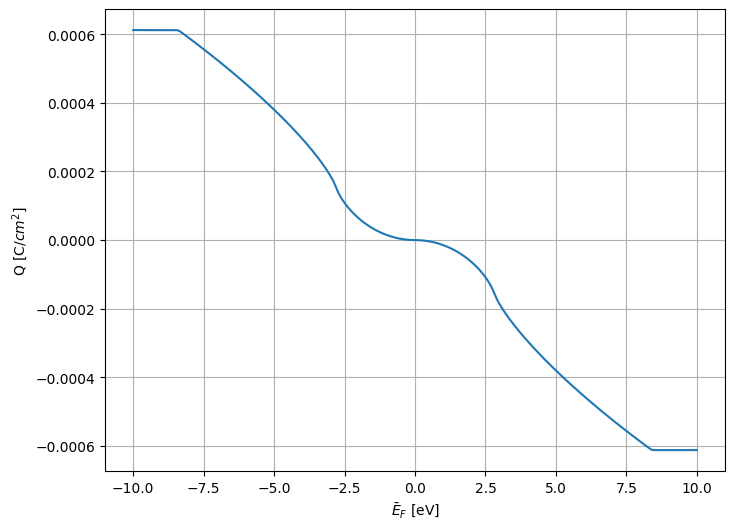

In [ ]:
E= np.linspace(-10,10,1000)
s= []
for e in E :
    
    s.append(G.get_net_density(e,300))

fig= plt.figure(figsize=(8,6))
ax = fig.add_subplot()

ax.grid(which='both')
ax.plot(E,np.array(s)*G.q*-1)

ax.set_ylabel(r'Q [C/$cm^2$]')
ax.set_xlabel(r'$\bar{E}_F$ [eV]')

plt.tight_layout
plt.show()

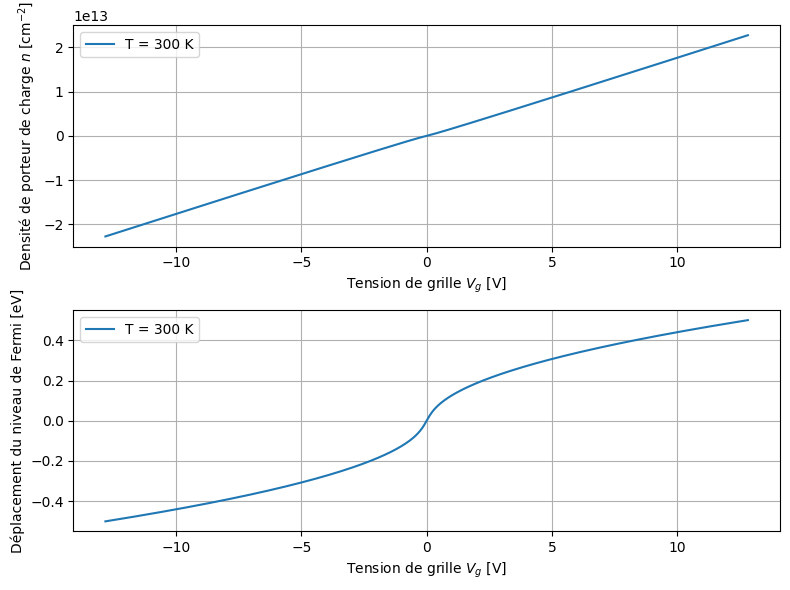

In [ ]:
eps_0 = 8.854e-14
eps_ox = 1
d_ox = 30e-8  # cm
C_ox = (eps_0 * eps_ox) / d_ox

Vg, n_porteurs, Ef_list = G.dep_Voltage(T=300, C_ox=C_ox,Ef_sup=0.5,Ef_inf=-0.5,N=2000)

fig= plt.figure(figsize=(8,6))
ax = fig.add_subplot(211)
ax2 = fig.add_subplot(212)

ax.grid(which='both')
ax.plot(Vg, n_porteurs, label='T = 300 K')
ax.legend()

ax.set_ylabel(r'Densité de porteur de charge $n$ [cm$^{-2}$]')
ax.set_xlabel(r'Tension de grille $V_g$ [V]')

ax2.grid(which='both')
ax2.plot(Vg, Ef_list, label='T = 300 K')
ax2.legend()

ax2.set_ylabel(r'Déplacement du niveau de Fermi [eV]')
ax2.set_xlabel(r'Tension de grille $V_g$ [V]')

plt.tight_layout()
plt.show()

In [ ]:
conduc = G.q**2 *100*G.v_F*np.sqrt(np.abs(n_porteurs)*np.pi)/(G.h/2)

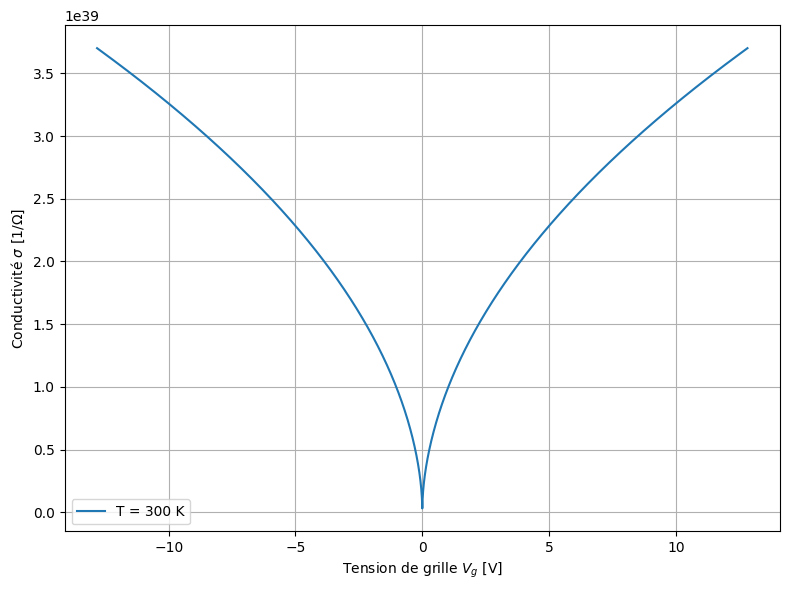

In [ ]:
fig= plt.figure(figsize=(8,6))
ax = fig.add_subplot(111)

ax.grid(which='both')
ax.plot(Vg, conduc, label='T = 300 K')
ax.legend()

ax.set_ylabel(r'Conductivité $\sigma$ [1/$\Omega$]')
ax.set_xlabel(r'Tension de grille $V_g$ [V]')

plt.tight_layout()
plt.show()